# Pruebas de hipótesis

Este notebook continúa el análisis a partir del dataset limpio generado en `exploration.ipynb`.


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import levene

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df_clean = pd.read_csv('../data/spotify_tracks_clean.csv')
print(f"Filas cargadas: {len(df_clean)}")

Filas cargadas: 89304


## Estadística descriptiva

A continuación calculamos estadísticas descriptivas para las variables numéricas del dataset limpio.


In [2]:
cols_interes = ['popularity', 'duration_ms', 'danceability', 'energy',
                    'key', 'loudness', 'mode', 'speechiness', 'acousticness', 
                    'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']

df_clean[cols_interes].describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,89304.000000,89304.000000,89304.000000,89304.000000,89304.000000,89304.000000,89304.000000,89304.000000,89304.000000,89304.000000,89304.000000,89304.000000,89304.000000,89304.000000
mean,33.218221,226193.581273,0.563580,0.635696,5.284903,-8.462489,0.636892,0.087509,0.327597,0.171935,0.216349,0.470803,122.289339,3.904708
std,20.600675,85616.416355,0.174968,0.255560,3.559889,5.169386,0.480898,0.113004,0.337903,0.322707,0.194105,0.262162,29.711613,0.422048
min,0.000000,15800.000000,0.051300,0.000020,0.000000,-46.591000,0.000000,0.022100,0.000000,0.000000,0.009250,0.000000,30.200000,1.000000
25%,19.000000,173053.000000,0.451000,0.459000,2.000000,-10.287250,0.000000,0.036000,0.017100,0.000000,0.098175,0.251000,99.533750,4.000000
50%,33.000000,213138.500000,0.577000,0.677000,5.000000,-7.168000,1.000000,0.049000,0.187000,0.000056,0.132000,0.459000,122.023000,4.000000
75%,49.000000,263693.000000,0.693000,0.854000,8.000000,-5.099000,1.000000,0.086000,0.623000,0.091025,0.278000,0.683000,140.094000,4.000000
max,100.000000,719306.000000,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


### Sesgo en las columnas

A partir de la tabla anterior, algunas columnas muestran sesgo notable:

- **Alto sesgo:** `instrumentalness`, `speechiness`, `acousticness`, `liveness`
- **Resto de columnas:** distribución relativamente equilibrada

Para profundizar, generaremos histogramas de las columnas relevantes.


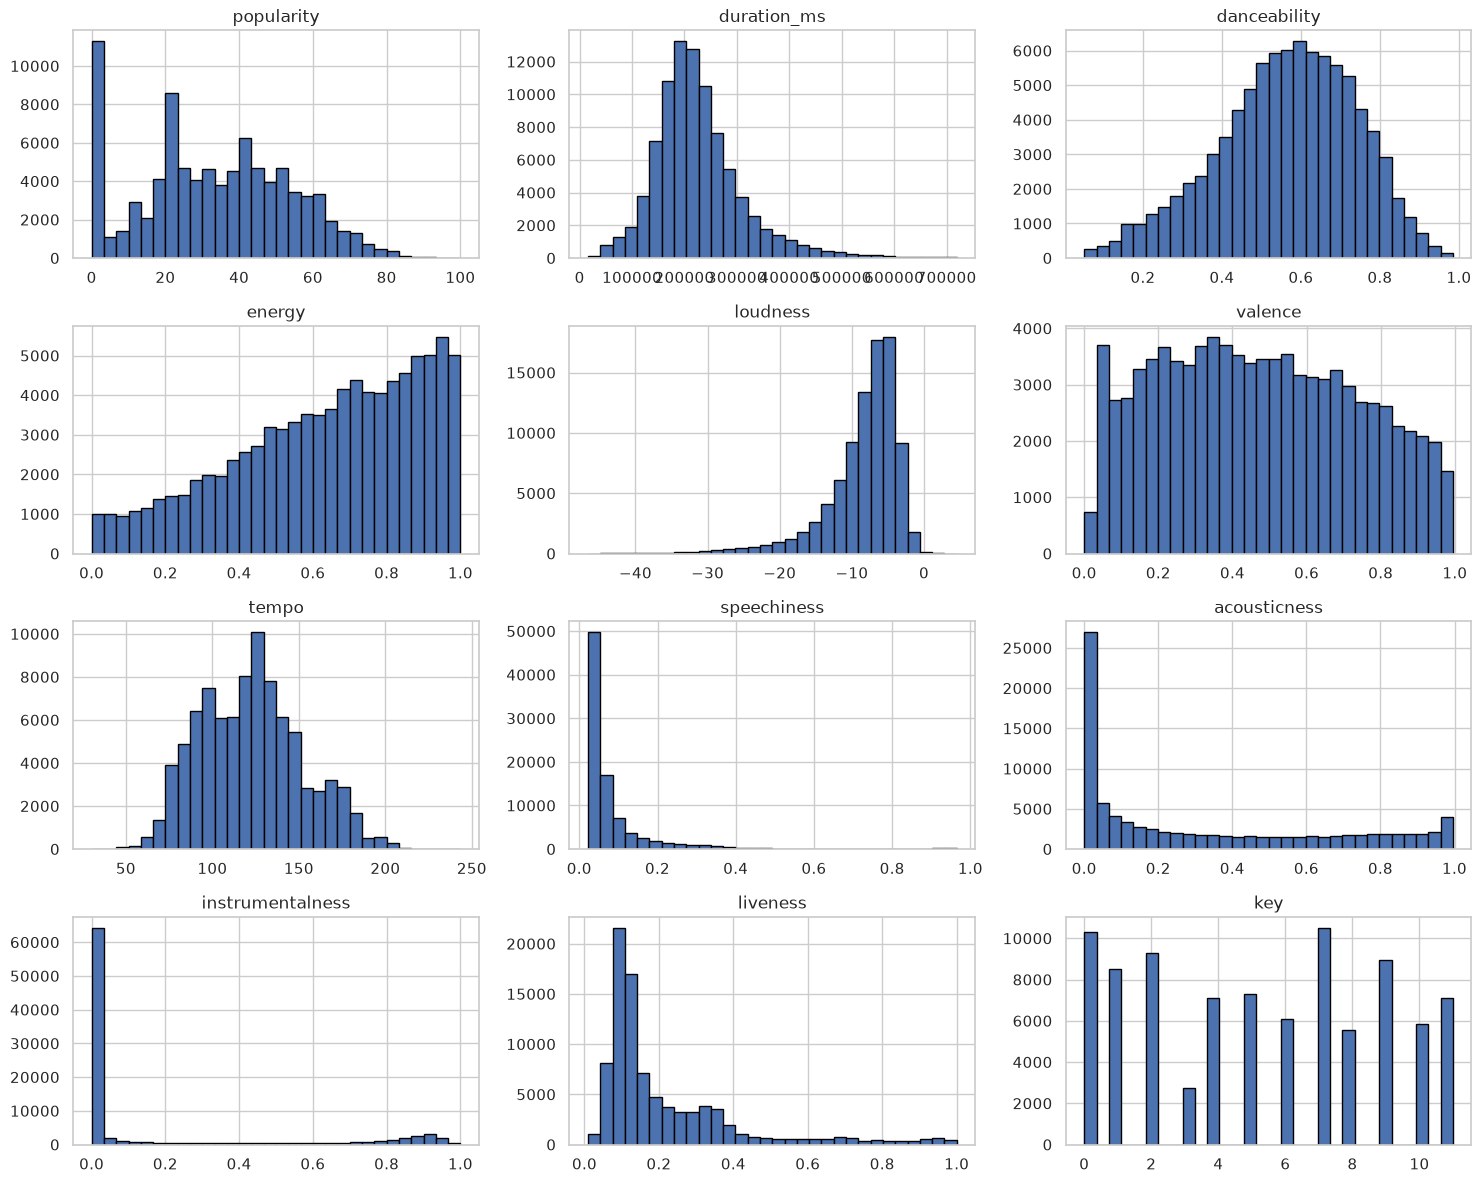

In [3]:
cols_clave = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 
              'valence', 'tempo', 'speechiness', 'acousticness', 
              'instrumentalness', 'liveness', 'key']

df_clean[cols_clave].hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

### Interpretación de la distribución

**Columnas con mayor sesgo:** `popularity`, `duration_ms`, `acousticness`, `instrumentalness`, `speechiness` y `liveness` concentran muchos valores en rangos específicos y presentan colas largas. También hay sesgo moderado en `tempo` y `loudness`.

**Columnas más equilibradas:** `danceability`, `energy` y `valence` muestran una distribución más uniforme, lo que las hace más estables para comparar canciones.

**Variables discretas:** `key`, `mode` y `time_signature` se comportan como variables categóricas, no continuas.


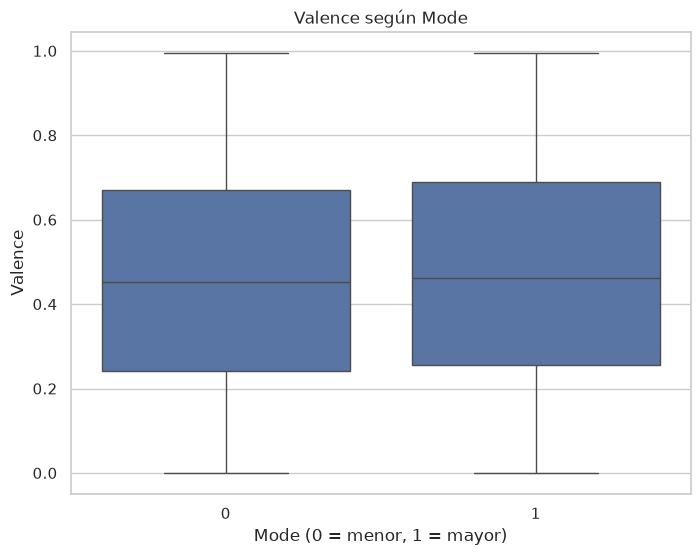

In [4]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='mode', y='valence', data=df_clean)
plt.xlabel('Mode (0 = menor, 1 = mayor)')
plt.ylabel('Valence')
plt.title('Valence según Mode')
plt.show()

## ¿Existe relación entre `mode` y `valence`?

Exploramos si la tonalidad de una canción (mayor o menor) se relaciona con su valencia emocional.

### Observación visual

El boxplot sugiere que **no hay una diferencia marcada** entre los grupos: los rangos intercuartílicos de `valence` son bastante similares para modo mayor y menor.

Aun así, contrastaremos las medias con pruebas estadísticas para distinguir variación aleatoria de un posible efecto de `mode`.

### Plan de pruebas

1. **Levene** — comprobar si las varianzas son iguales (supuesto del *t-test* de Student).
2. ***t*-test de Welch** — comparar medias cuando no conocemos la varianza poblacional o las varianzas difieren.
3. **Cohen's *d*** — medir si la diferencia, aunque significativa, tiene relevancia práctica.

> La librería `scipy.stats` facilita estos cálculos. Para más detalle sobre cada prueba, conviene revisar la teoría detrás de cada una.


### Comprobación de varianzas (test de Levene)

Antes del *t-test*, verificamos si las varianzas de ambos grupos son equivalentes.

Usamos **Levene** en lugar de un test basado en χ² porque no podemos asumir normalidad en las poblaciones. El p-value resultante nos indica si las varianzas pueden considerarse iguales.


In [5]:
from scipy import stats
from scipy.stats import levene

mayor = df_clean[df_clean['mode'] == 1]['valence']
menor = df_clean[df_clean['mode'] == 0]['valence']

print(f"Valence promedio - Modo mayor: {mayor.mean():.4f}")
print(f"Valence promedio - Modo menor: {menor.mean():.4f}")
print(f"tamaño de muestra - Modo mayor: {len(mayor)}")
print(f"tamaño de muestra - Modo menor: {len(menor)}")

stat, p_levene = levene(mayor, menor)
print(f"Levene p-value: {p_levene:.5f}")

Valence promedio - Modo mayor: 0.4759
Valence promedio - Modo menor: 0.4619
tamaño de muestra - Modo mayor: 56877
tamaño de muestra - Modo menor: 32427
Levene p-value: 0.00973


### Resultado de Levene

Con **p-value = 0,00973** (< 0,05), rechazamos la hipótesis de varianzas iguales.

**Implicación:** no aplicamos el *t-test* de Student; usamos el **t-test de Welch** (`equal_var=False`), válido cuando las varianzas difieren.


In [6]:
#ttest es t-test welch puesto que equal_var=False
t_stat, p_value = stats.ttest_ind(mayor, menor, equal_var=False)
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.10f}")

t-statistic: 7.664
p-value: 0.0000000000


### Resultado del t-test de Welch

El **p-value ≈ 0** indica que la diferencia entre medias es **estadísticamente significativa** (no parece deberse al azar).

> ⚠️ Con muestras muy grandes (~89.000 registros), un p-value bajo no implica necesariamente un efecto **relevante** en la práctica.

Por eso calculamos el **tamaño del efecto** con Cohen's *d*.


In [7]:
import numpy as np

def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    #Varianza de cada grupo
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    #Desviación estandar combinada
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (group1.mean() - group2.mean()) / pooled_std

d = cohens_d(mayor, menor)
print(f"Cohen's d: {d:.4f}")

Cohen's d: 0.0532


## Conclusión: ¿Hay relación entre `mode` y `valence`?

### Definición de las variables

| Variable | Descripción |
|----------|-------------|
| **`mode`** | Tonalidad: `0` = menor (suele sonar triste), `1` = mayor (suele sonar alegre) |
| **`valence`** | Estado de ánimo: valores altos = positivo/alegre, valores bajos = negativo/triste |

### Resumen del análisis

| Paso | Resultado |
|------|-----------|
| Boxplot | Distribuciones muy similares entre modos |
| Media modo mayor | 0,4759 |
| Media modo menor | 0,4619 |
| Diferencia absoluta | 0,014 (~1,4 puntos porcentuales) |
| *t*-test de Welch | p-value ≈ 0 → diferencia significativa |
| Cohen's *d* | **0,0532** → efecto **despreciable** (< 0,2) |

### Interpretación

La intuición musical sugiere que las canciones en **modo mayor** deberían tener mayor `valence`. Los datos muestran una tendencia mínima en esa dirección, pero:

1. **Visualmente**, las distribuciones casi se superponen.
2. **Estadísticamente**, la diferencia es significativa — sobre todo porque el tamaño muestral es enorme (~89.000 canciones).
3. **Prácticamente**, Cohen's *d* = 0,053 indica un efecto **despreciable**: la diferencia entre medias no llega ni al **20%** de una desviación estándar.

### Conclusión final

**No hay una relación aparente ni relevante entre `mode` y `valence` en este dataset.** Aunque el test rechaza la hipótesis nula, el tamaño del efecto es tan pequeño que, para fines analíticos o de modelado, `mode` no parece ser un predictor útil de la valencia emocional de una canción.


## ¿Existe relación entre `tempo` y `energy`?

Exploramos si la velocidad de una canción se relaciona linealmente con su nivel de energía percibida.

### Definición de las variables

| Variable | Descripción |
|----------|-------------|
| **`tempo`** | Velocidad de la canción, medida en pulsaciones por minuto (BPM) |
| **`energy`** | Nivel de energía percibida: `0` = calmada/suave, `1` = muy enérgica/intensa |

### Plan de prueba

Como ambas variables son **continuas**, usamos la **correlación de Pearson** para evaluar si existe una relación lineal entre ellas.

| Hipótesis | Enunciado |
|-----------|-----------|
| **H₀** | No hay correlación lineal entre `tempo` y `energy` (*r* = 0) |
| **H₁** | Sí hay correlación lineal (*r* ≠ 0) |

Visualizaremos la relación con un scatter plot y complementaremos con el coeficiente de determinación (*r*²) para evaluar la relevancia práctica.


In [8]:
from scipy import stats

corr, p_value = stats.pearsonr(df_clean['tempo'], df_clean['energy'])
print(f"Correlación de Pearson (r): {corr:.4f}")
print(f"p-value: {p_value:.10f}")

Correlación de Pearson (r): 0.2487
p-value: 0.0000000000


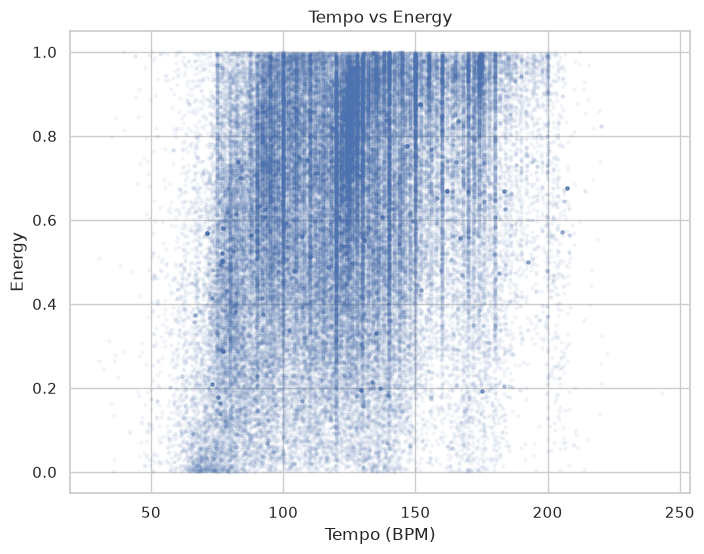

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(df_clean['tempo'], df_clean['energy'], alpha=0.05, s=5)
plt.xlabel('Tempo (BPM)')
plt.ylabel('Energy')
plt.title('Tempo vs Energy')
plt.show()

## Conclusión: ¿Hay relación entre `tempo` y `energy`?

### Resumen del análisis

| Paso | Resultado |
|------|-----------|
| Correlación de Pearson (*r*) | **0,2487** → relación **débil a moderada** |
| p-value | ≈ 0 → correlación estadísticamente significativa |
| Coeficiente de determinación (*r*²) | **0,062** → `tempo` explica ~**6,2%** de la variabilidad de `energy` |
| Scatter plot | Tendencia positiva visible, pero con mucha dispersión |

### Interpretación

El **p-value < 0,05** confirma que existe una correlación lineal significativa entre `tempo` y `energy`. Sin embargo:

1. **Magnitud:** con *r* ≈ 0,25, la relación se clasifica como **débil a moderada** (no fuerte).
2. **Varianza explicada:** *r*² = 0,062 indica que el tempo solo captura ~6,2% de la variación en energía.
3. **Implicación práctica:** el resto de la variabilidad probablemente depende de otras variables como `loudness` o el género musical.

### Conclusión final

**Sí existe una relación lineal entre `tempo` y `energy`, pero es débil.** Aunque es estadísticamente significativa, `tempo` por sí solo no es un predictor suficiente de la energía percibida de una canción.


## ¿Existe relación entre `loudness` y `energy`?

Exploramos si el volumen general de una canción se relaciona con su nivel de energía percibida.

### Definición de las variables

| Variable | Descripción |
|----------|-------------|
| **`loudness`** | Volumen general de la canción, medido en decibelios (dB). Valores más altos (menos negativos) indican mayor intensidad sonora |
| **`energy`** | Nivel de energía percibida: `0` = calmada/suave, `1` = muy enérgica/intensa |

### Plan de prueba

Como ambas variables son **continuas**, aplicamos correlación de **Pearson** para evaluar una relación lineal. Si el scatter plot sugiere no linealidad, complementamos con **Spearman** (correlación monótona).

| Hipótesis | Enunciado |
|-----------|-----------|
| **H₀** | No hay correlación lineal entre `loudness` y `energy` (*r* = 0) |
| **H₁** | Sí hay correlación lineal (*r* ≠ 0) |


> **Expectativa:** a diferencia de `tempo`, aquí anticipamos una relación **más fuerte**, ya que ambas variables capturan aspectos de la intensidad sonora de la canción.

In [10]:
corr, p_value = stats.pearsonr(df_clean['loudness'], df_clean['energy'])
print(f"Correlación de Pearson (r): {corr:.4f}")
print(f"p-value: {p_value:.10f}")

Correlación de Pearson (r): 0.7592
p-value: 0.0000000000


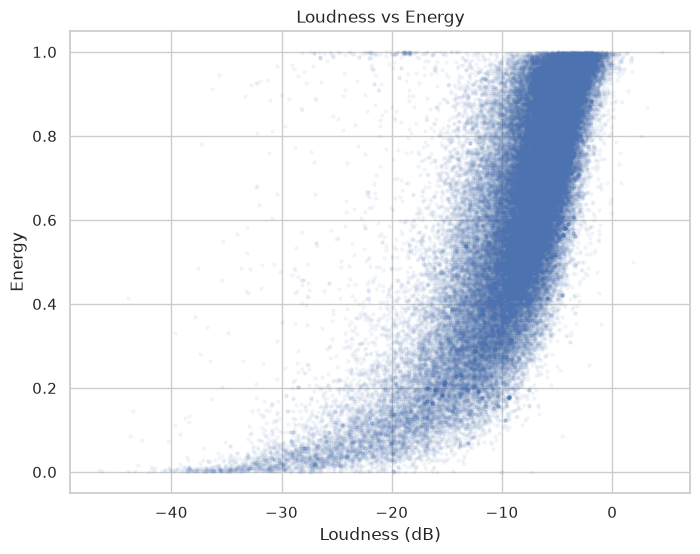

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(df_clean['loudness'], df_clean['energy'], alpha=0.05, s=5)
plt.xlabel('Loudness (dB)')
plt.ylabel('Energy')
plt.title('Loudness vs Energy')
plt.show()

#### Análisis de No-Linealidad

La gráfica de dispersión sugiere una posible **relación curva y no lineal** entre las variables **Loudness** (Sonoridad) y **Energy** (Energía). 

Para verificar esta hipótesis de forma rigurosa, calcularemos el **Coeficiente de Correlación de Spearman**. Este indicador evalúa si las variables cambian juntas en una dirección constante, sin exigir que lo hagan a un ritmo constante (relación monótona).

> 💡 **Criterio de Validación:**  
> Si el coeficiente de Spearman resulta ser **significativamente mayor** que el de Pearson, confirmaremos la existencia de una relación no lineal que el análisis de Pearson no es capaz de capturar correctamente.


In [13]:
corr_spearman, p_spearman = stats.spearmanr(df_clean['loudness'], df_clean['energy'])
print(f"Correlación de Spearman: {corr_spearman:.4f}")
print(f"p-value: {p_spearman:.10f}")

Correlación de Spearman: 0.7527
p-value: 0.0000000000


El coeficiente de Spearman resulto casi identico al de Pearson por lo tanto podemos asegurar que la relación entre Loudness y Energy es mayormente lineal. 

### Resultado de Pearson y observación visual

| Métrica | Resultado |
|---------|-----------|
| Correlación de Pearson (*r*) | **0,7592** → relación **fuerte** |
| p-value | ≈ 0 → correlación estadísticamente significativa |
| Coeficiente de determinación (*r*²) | **~0,576** → `loudness` explica ~**57,6%** de la variabilidad de `energy` |

Con *r* ≈ 0,75 podemos afirmar que existe una **relación fuerte y positiva** entre `loudness` y `energy`.

